# Examples of Custom States and Operators

The [State](../apidoc/_autosummary/pulser.backend.State.rst) and [Operator](../apidoc/_autosummary/pulser.backend.Operator.rst) classes let you build arbitrary state and operator objects from scratch using the `from_state_amplitudes()` and `from_operator_repr()` methods. A common use case for this is many-body physics simulations, where you often want to:

- prepare reference initial states that are non-trivial.
- scale the number of qubits $L$ to look for trends that persist (or not).

This tutorial shows examples of how to parametrize the `from_state_amplitudes()` and `from_operator_repr()` methods by the system size.

## Size-parametrized helper class for Pauli operators

For a two-level system with `eigenstates = ("r", "g")`, the Pauli matrices are written as:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pulser_simulation import QutipConfig

eigenstates = ("r", "g")

sigma_repr = {
    "x": {"gr": 1.0, "rg": 1.0},
    "y": {"gr": 1.0j, "rg": -1.0j},
    "z": {"rr": 1.0, "gg": -1.0},
}

Instead of repeating `eigenstates` and `n_qudits` at every call, it is convenient to wrap them in a small class indexed by the number of qubits `L`. The `corr_pauli` method below builds the operator for a product of identical Pauli matrices acting on an arbitrary subset of sites (e.g. `corr_pauli("x", 0, 2)` builds $X_0 X_2$), and `get_state` builds a few reference states of size `L`. `QutipConfig` has been used below as an example for the backend config class.

In [2]:
class Chain:
    """A qubit chain of a given size, with helpers to build Pauli-string
    operators and a few reference states."""

    def __init__(self, L, config_class=QutipConfig):
        self.L = L
        self.eigenstates = eigenstates
        self.state_class = config_class.state_type
        self.operator_class = config_class.operator_type

    def corr_pauli(self, a, *idxs):
        """Builds the operator for a Pauli string, e.g. corr_pauli("x", 0, 2)
        builds X_0 X_2. Does not support mixed Pauli operators, such as X_0 Z_1.
        """
        # lists and tuples are also supported as inputs
        # sets are used to remove duplicates
        if len(idxs) == 1 and not isinstance(idxs[0], int):
            idx = set(idxs[0])
        else:
            idx = set(idxs)

        return self.operator_class.from_operator_repr(
            eigenstates=self.eigenstates,
            n_qudits=self.L,
            operations=[(1.0, [(sigma_repr[a], idx)])],
        )

    def get_state(self, state_name):
        """Builds few reference states of size L."""
        if state_name == "plus":
            # |+>^L : uniform superposition of all basis states
            dim = 2**self.L
            amplitudes = {
                "".join(
                    self.eigenstates[int(b)]
                    for b in format(i, f"0{self.L}b")
                    # this converts the integer i into a binary string of a fixed length (self.L)
                ): 1.0
                / np.sqrt(dim)
                for i in range(dim)
            }
            return self.state_class.from_state_amplitudes(
                eigenstates=self.eigenstates, amplitudes=amplitudes
            )

        elif state_name == "ghz":
            # (|rr...r> + |gg...g>) / sqrt(2)
            norm = 1.0 / np.sqrt(2)
            return self.state_class.from_state_amplitudes(
                eigenstates=self.eigenstates,
                amplitudes={"r" * self.L: norm, "g" * self.L: norm},
            )

        else:
            raise NotImplementedError(f"State {state_name} not implemented.")

`corr_pauli` and `get_state` both only depend on `self.L`, so the exact same
code can be reused to build operators and states for any system size, and
they are built directly with `from_operator_repr()` /
`from_state_amplitudes()`, so they remain compatible with remote backends.

In [3]:
system = Chain(L=4)

x0 = system.corr_pauli("x", 0)  # X_0
z1z3 = system.corr_pauli("z", [1, 3])  # Z_1 Z_3, indices as a list also works

z1z3.to_qobj()

Quantum object: dims=[[2, 2, 2, 2], [2, 2, 2, 2]], shape=(16, 16), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0. 

## Building reference states

The same `Chain` class also builds reference states via `get_state()`, using `from_state_amplitudes()`. Below, the `"plus"` and `"ghz"` states are built for the same `system` and compared by their bitstring probabilities, obtained with `bitstring_probabilities()`.

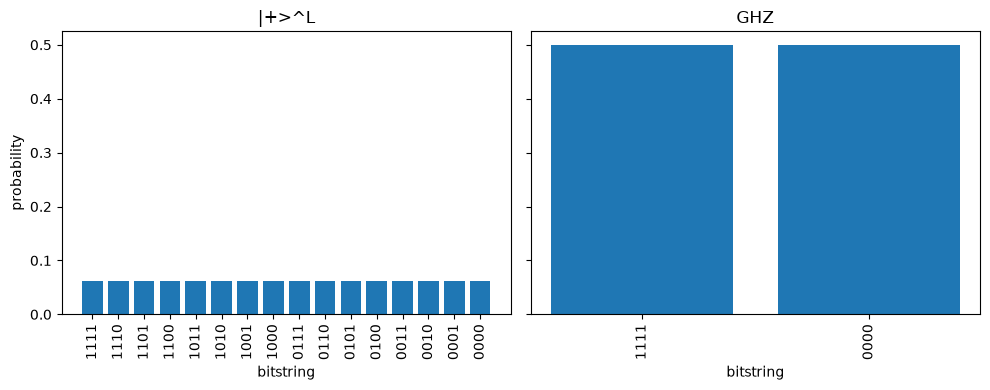

In [4]:
plus_state = system.get_state("plus")
ghz_state = system.get_state("ghz")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, state, title in zip(axes, (plus_state, ghz_state), ("|+>^L", "GHZ")):
    probs = state.bitstring_probabilities()
    ax.bar(probs.keys(), probs.values())
    ax.set_title(title)
    ax.set_xlabel("bitstring")
    ax.tick_params(axis="x", rotation=90)

axes[0].set_ylabel("probability")
fig.tight_layout()

## Summary

`corr_pauli` and `get_state` show that once a helper is written in terms of `from_operator_repr()` / `from_state_amplitudes()` and a size parameter `L`, it can build states and operators for any system size without any change to the code, and stays compatible with remote backends since nothing is tied to a particular register or device.